# 4 — From a Gaussian in the coefficients to a statement about $p(R)$

*Series: **Bayesian fluorescence decays**, notebook 4 of 8. Builds §6 of
`THEORY.md`.*

**What this notebook establishes.** That the obvious way to report the
posterior — draw from it and look at what comes out — is wrong here, why, and
what replaces it.

---

## The situation

Notebook 3 left a posterior of the form

$$
\pi(\theta\mid y)\;\approx\;\sum_\ell w_\ell\,\mathcal N\big(\hat\theta_\ell,\,\Sigma_\ell\big),
$$

a mixture of Gaussians in $\theta$. But nobody wants $\theta$. What is wanted
is $p(R)$, and numbers computed from it: its mean, its width, the mass beyond
some distance, the fraction of molecules with no acceptor. Those are related
to $\theta$ by

$$
p(r_j)=\operatorname{softmax}(\Phi c)_j,
$$

which is smooth but **very** nonlinear — and a Gaussian pushed through it is
not what one might guess.

In [1]:
import sys, time, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
import numpy as np, matplotlib.pyplot as plt, torch
import bd
bd.keep_inline()          # the prototype's modules switch matplotlib to a file backend on import

S = bd.default_settings(); S['threads'] = 4
model = bd.build_model(S)
L, rel = model['L'], model['rel']
p_true = bd.gaussian_truth(model, [0.85, 1.15], [0.55, 0.45], 0.06)
y, lam_true, vals_true = bd.simulate_ensemble(model, S, p_true, x_d0=0.2, photons=3e5, seed=3)
t0 = time.time()
nodes = [bd.fit_at_lambda(model, y, lg) for lg in (1.0, 0.0, -1.0)]
post = bd.mix_nodes(nodes)
print(f'three nodes in {time.time()-t0:.0f} s; weights ' +
      '  '.join(f"{n['log10_lam']:+.0f}: {w:.3f}" for n, w in zip(nodes, post['weights'])))
best = post['nodes'][post['best_lam']]
print(f"parameter dimension {best['graph'].dim}, D/dof {post['dev']/post['dof']:.4f} at dof {post['dof']}")
print('figure backend', bd.assert_inline())

  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt
three nodes in 105 s; weights +1: 0.810  +0: 0.188  -1: 0.002
parameter dimension 114, D/dof 1.0674 at dof 1694
figure backend inline


## What happens if you just draw

Take the Gaussian at the best node, draw from it, and push each draw through
the softmax. The Gaussian is a *local* approximation and the softmax is a
wall: a draw that is unremarkable in $c$ — a couple of standard deviations out
along a direction the data barely constrain — becomes a spike in $p$, because
the exponential turns a moderate coefficient excursion into an enormous
density excursion.

The upper quantiles of the drawn ensemble therefore say something the
posterior does not mean.

at R/R0 = 1.61, where the truth has 4.09e-15:
  drawn 97.5 % quantile   2.751e-02
  delta-method +2 sd      1.575e-02
  ratio                   1.7
largest drawn value anywhere: 1.477e-01, against a posterior mean peak of 1.799e-02


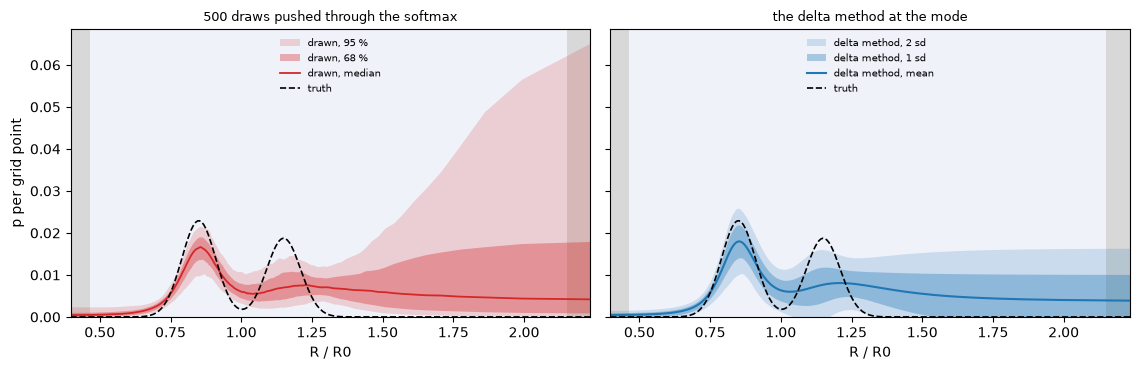

In [2]:
gnode = best['graph']
th, Sig = best['theta'], best['Sigma']
Lc = torch.linalg.cholesky(Sig + 1e-12 * torch.eye(len(th), dtype=Sig.dtype))
gen = torch.Generator().manual_seed(7)
n_draw = 500
Z = torch.randn(len(th), n_draw, generator=gen, dtype=Sig.dtype)
draws = th[:, None] + Lc @ Z
P = np.zeros((n_draw, len(rel)))
for i in range(n_draw):
    v, _ = gnode.unpack(draws[:, i])
    P[i] = gnode.distribution(v).detach().numpy()
q = np.quantile(P, [0.025, 0.16, 0.5, 0.84, 0.975], axis=0)
m_d, lo1, hi1, lo2, hi2 = L.delta_bands(None, post, rel, space='linear')
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8), sharey=True)
ax[0].fill_between(rel, q[0], q[4], color='C3', alpha=0.18, lw=0, label='drawn, 95 %')
ax[0].fill_between(rel, q[1], q[3], color='C3', alpha=0.35, lw=0, label='drawn, 68 %')
ax[0].plot(rel, q[2], 'C3', lw=1.3, label='drawn, median')
ax[1].fill_between(rel, lo2, hi2, color='C0', alpha=0.18, lw=0, label='delta method, 2 sd')
ax[1].fill_between(rel, lo1, hi1, color='C0', alpha=0.35, lw=0, label='delta method, 1 sd')
ax[1].plot(rel, m_d, 'C0', lw=1.5, label='delta method, mean')
for a, ttl in zip(ax, (f'{n_draw} draws pushed through the softmax', 'the delta method at the mode')):
    a.plot(rel, p_true, 'k--', lw=1.2, label='truth')
    a.set_xlabel('R / R0'); a.set_xlim(rel[0], rel[-1]); a.set_title(ttl, fontsize=9)
    L.shade_window(a, 0.01, label=False); a.legend(fontsize=7, frameon=False)
ax[0].set_ylabel('p per grid point')
ax[0].set_ylim(0, max(q[4].max(), hi2.max()) * 1.05)
fig.tight_layout()
j_hi = int(np.argmax(rel > 1.6))
print(f'at R/R0 = {rel[j_hi]:.2f}, where the truth has {p_true[j_hi]:.2e}:')
print(f'  drawn 97.5 % quantile   {q[4][j_hi]:.3e}')
print(f'  delta-method +2 sd      {hi2[j_hi]:.3e}')
print(f'  ratio                   {q[4][j_hi]/max(hi2[j_hi],1e-300):.1f}')
print(f'largest drawn value anywhere: {P.max():.3e}, against a posterior mean peak of {m_d.max():.3e}')

## The delta method

The fix is to linearise the map rather than to sample it. For any functional
$T(\theta)$ — a single grid point of $p$, or a summary of it —

$$
\mathbb E[T]\approx T(\hat\theta),
\qquad
\operatorname{Var}[T]\approx \nabla T(\hat\theta)^{\!\top}\,\Sigma\,\nabla T(\hat\theta),
$$

evaluated per node, and then combined over the mixture with the law of total
variance,

$$
\mu=\sum_\ell w_\ell\mu_\ell,
\qquad
\sigma^2=\sum_\ell w_\ell\big[\sigma_\ell^2+(\mu_\ell-\mu)^2\big].
$$

The gradient $\nabla T$ is exact, by automatic differentiation through the
same forward model that produced the fit. The approximation is only that $T$
is locally linear over the posterior's width — which is precisely what the
draws above violate in the tail, and precisely what is true where the data
have something to say.

## And the space the band is drawn in

A band in $p$ can go negative; a band in $\log p$ cannot. The second sounds
better and is much worse. Where $p$ is empty, the Laplace standard deviation
of $\log p$ is enormous — those are flat directions of the posterior — and
$\exp(m+2\sigma)$ reaches values with no meaning at all. That was tried in
this project and produced figures whose vertical axis was set by a spike
outside the measurable window.

The band is therefore taken in $p$, and its lower edge clipped at zero. Both
are drawn below on the same fit.

largest upper edge: in p 2.587e-02; as a lognormal 1.569e-01
the lognormal upper edge exceeds the posterior mean peak by a factor 8.72


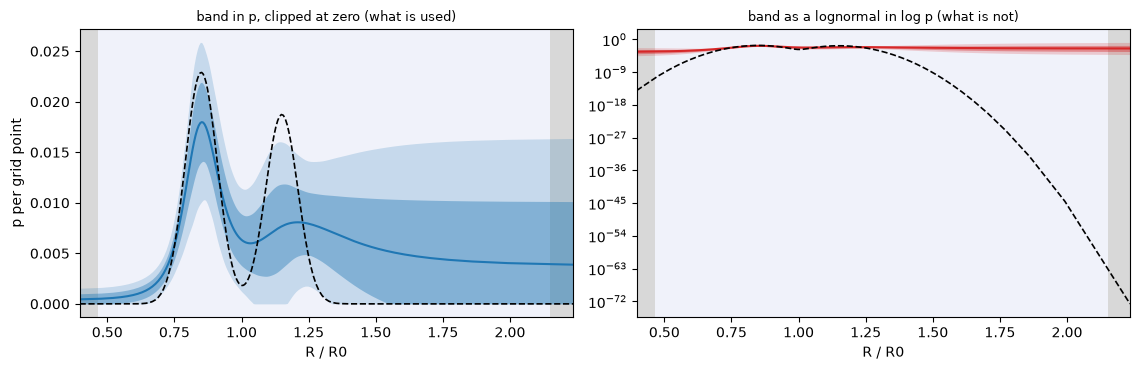

In [3]:
m_l, lo1l, hi1l, lo2l, hi2l = L.delta_bands(None, post, rel, space='log')
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax[0].fill_between(rel, lo2, hi2, color='C0', alpha=0.2, lw=0)
ax[0].fill_between(rel, lo1, hi1, color='C0', alpha=0.4, lw=0)
ax[0].plot(rel, m_d, 'C0', lw=1.5); ax[0].plot(rel, p_true, 'k--', lw=1.2)
ax[0].set_ylabel('p per grid point'); ax[0].set_title('band in p, clipped at zero (what is used)', fontsize=9)
ax[1].fill_between(rel, lo2l, hi2l, color='C3', alpha=0.2, lw=0)
ax[1].fill_between(rel, lo1l, hi1l, color='C3', alpha=0.4, lw=0)
ax[1].plot(rel, m_l, 'C3', lw=1.5); ax[1].plot(rel, p_true, 'k--', lw=1.2)
ax[1].set_yscale('log'); ax[1].set_title('band as a lognormal in log p (what is not)', fontsize=9)
for a in ax:
    a.set_xlabel('R / R0'); a.set_xlim(rel[0], rel[-1]); L.shade_window(a, 0.01, label=False)
fig.tight_layout()
print(f'largest upper edge: in p {hi2.max():.3e}; as a lognormal {hi2l.max():.3e}')
print(f'the lognormal upper edge exceeds the posterior mean peak by a factor {hi2l.max()/m_d.max():.3g}')

## The summaries, and intervals that can cross a boundary

The numbers actually reported are functionals of the distribution:

$$
\bar r=\sum_j r_j p_j,\qquad
\sigma_r=\Big[\sum_j (r_j-\bar r)^2 p_j\Big]^{1/2},\qquad
\text{tail}=\sum_{r_j>1.3} p_j,
$$

together with the donor-only fraction and the calibration constants. Each gets
a mean and a standard deviation by the delta method per node, mixed as above,
and an interval from the mixture's cumulative distribution — which is a sum of
normal CDFs and therefore available in closed form.

Those intervals are Gaussian, so an interval on a quantity bounded below by
zero can reach past zero. That is not a bug to be hidden by truncation: a
negative lower edge on the tail mass means **the data do not exclude zero**,
and truncating it would claim otherwise.

In [4]:
mu_t = float((p_true * rel).sum())
truth = dict(x_d0=0.2, mean=mu_t, sd=float(np.sqrt((p_true * (rel - mu_t) ** 2).sum())),
             tail=float(p_true[rel > 1.3].sum()), r0_d=S['r0_donor'], r0_a=S['r0_acceptor'], g=L.S.G_TRUE)
rows = bd.summary_table(model, post, truth)
print(f"{'quantity':<9}{'truth':>9}{'posterior':>11}{'sd':>9}{'95 % interval':>22}{'rank':>8}")
mom = L.mixture_summary_moments(post['graph'], post, rel)
for r in rows:
    cdf = L.mixture_cdf(mom, r['quantity'], r['truth'])
    print(f"{r['quantity']:<9}{r['truth']:>9.4f}{r['mean']:>11.4f}{r['sd']:>9.4f}"
          f"   [{r['lo']:+.4f}, {r['hi']:+.4f}]{cdf:>8.3f}")
print('\nthe rank is the posterior probability below the truth; over many data sets')
print('these must be uniform, which is the calibration check of notebook 5.')

quantity     truth  posterior       sd         95 % interval    rank
x_d0        0.2000     0.1333   0.0613   [+0.0104, +0.2502]   0.863
mean        0.9694     1.0234   0.0527   [+0.9238, +1.1297]   0.151
sd          0.1504     0.2420   0.0727   [+0.1012, +0.3854]   0.104
tail        0.0018     0.1258   0.0930   [-0.0573, +0.3069]   0.092
r0_d        0.3600     0.3510   0.0089   [+0.3336, +0.3684]   0.844
r0_a        0.1800     0.1679   0.0079   [+0.1524, +0.1833]   0.938
g           1.1500     1.1519   0.0045   [+1.1430, +1.1608]   0.335

the rank is the posterior probability below the truth; over many data sets
these must be uniform, which is the calibration check of notebook 5.


## A gauge that has to be canonical

The softmax is shift invariant: $c$ and $c+\alpha\mathbf 1$ give the same
distribution. That flat direction has to be removed or the Hessian is
singular, and it is removed by working in a sum-to-zero basis,
$c = \mathbf{K}\tilde c$ with $\mathbf K$ an orthonormal basis of
$\mathbf 1^\perp$.

Any such $\mathbf K$ gives the same posterior over $p$ — but not the same
*coordinates*, and a posterior stored as numbers in one basis is meaningless
in another. Taking $\mathbf K$ from the singular vectors of a degenerate
subspace makes it depend on the machine's linear algebra, and a posterior
computed on one machine then restores wrongly on another. That happened in
this project, to a thousand stored fits.

**Helmert contrasts** are the fix: an explicit, canonical, machine-independent
orthonormal basis of $\mathbf 1^\perp$. The check below is that the gauge is
orthonormal, that it annihilates the constant, and that the distribution is
invariant to a shift along the removed direction.

In [5]:
n_c = model['spl'].shape[1]
K = np.asarray(L.helmert_basis(n_c))
print('Helmert basis', K.shape)
print(f'  orthonormal columns:        max |K^T K - I| = {np.abs(K.T @ K - np.eye(K.shape[1])).max():.2e}')
print(f'  orthogonal to the constant: max |1^T K|     = {np.abs(K.sum(0)).max():.2e}')
v, _ = gnode.unpack(best['theta'])
p0 = gnode.distribution(v).detach().numpy()
v2 = dict(v); v2['c'] = v['c'] + 3.7
p2 = gnode.distribution(v2).detach().numpy()
print(f'  softmax shift invariance:  max |p(c) - p(c + 3.7)| = {np.abs(p0 - p2).max():.2e}')
K2 = np.asarray(L.helmert_basis(n_c))
print(f'  reproducible across calls:  max |K - K2|     = {np.abs(K - K2).max():.2e}')

Helmert basis (25, 24)
  orthonormal columns:        max |K^T K - I| = 2.22e-16
  orthogonal to the constant: max |1^T K|     = 4.44e-16
  softmax shift invariance:  max |p(c) - p(c + 3.7)| = 2.08e-17
  reproducible across calls:  max |K - K2|     = 0.00e+00


## What comes next

There is now a posterior, a band, and a table of numbers with intervals. None
of that says the intervals are *right*. Notebook 5 asks whether they are, by
simulating truths and counting how often the interval contains the answer —
and by measuring how close two populations can be before the method stops
seeing two.

**Established here.** Why draws through the softmax overshoot (THEORY §6.1),
measured; the delta method and its mixture combination (§6.2); the band in $p$
against the lognormal in $\log p$ (§6.2); mixture quantiles and ranks (§6.3);
and the sum-to-zero gauge with the Helmert basis that makes it canonical
(§3).